Here, we filter the TF anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [24]:
import os
import ast
import json
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

# from scipy.stats import f_oneway, kruskal
# from scipy import stats
# from sklearn.metrics import normalized_mutual_info_score
# from sklearn.linear_model import LinearRegression, LogisticRegression
# from sklearn.cross_decomposition import PLSRegression
# from sklearn.preprocessing import LabelBinarizer, LabelEncoder, StandardScaler, OneHotEncoder
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.pipeline import make_pipeline

# from kneed import KneeLocator

import scanpy as sc
# import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
from scLEMBAS import latent_separation as ls

In [25]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'

file_path = os.path.join(data_path, 'processed', author + '_ligand_connections.json')
with open(file_path, 'r') as f:
    ligand_connections = json.load(f)
    
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', author + 'consensus_tf_activity.h5ad'))


In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'

In [5]:
tf_labels = tf_adata.var.index.unique().tolist()
ppi_nodes = set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist())
retained_drugs = [drug for drug, TFs in ligand_connections.items() if len(TFs) != 0]
retained_drugs.append('DMSO_TF')
retained_TFs = ppi_nodes.intersection(tf_labels)

Filter the TF object to only include those samples / features retained in the signaling network:

In [6]:
n_cells = tf_adata.shape[0]
tf_adata = tf_adata[tf_adata.obs.drug.isin(retained_drugs), sorted(retained_TFs)]
print('{} of {} cells are retained after excluding drugs not present in the signaling network'.format(tf_adata.shape[0], 
                                                                                                     n_cells))

608710 of 734650 cells are retained after excluding drugs not present in the signaling network


In [7]:
obs = tf_adata.obs.copy()
n_cl, n_drug, n_cond = obs.cell_line.nunique(), obs.drug.nunique(), obs.condition.nunique()

print('The final {} conditions span {} cell lines and {} drugs'.format(n_cond, n_cl, n_drug))

The final 290 conditions span 10 cell lines and 29 drugs


In [8]:
url = "https://huggingface.co/datasets/tahoebio/Tahoe-100M/resolve/main/metadata/drug_metadata.parquet"
drug_ds = pd.read_parquet(url)
n_moa = drug_ds[drug_ds.drug.isin(retained_drugs)]['moa-fine'].nunique()

url = 'https://huggingface.co/datasets/tahoebio/Tahoe-100M/resolve/main/metadata/cell_line_metadata.parquet'
cell_line_md = pd.read_parquet(url)
cell_line_md = cell_line_md[cell_line_md.Cell_ID_Cellosaur.isin(tf_adata.obs.cell_line.unique().tolist())]

print('This represents {} moas, {} organs, and {} driver genes'.format(n_moa, 
                                                         cell_line_md.Organ.nunique(), 
                                                         cell_line_md.Driver_Gene_Symbol.nunique()))
print('See notebook 00A for the starting numbers prior to signaling network filtering')

This represents 12 moas, 5 organs, and 39 driver genes
See notebook 00A for the starting numbers prior to signaling network filtering


Only one MOA is lost from the drug filtering.

In [9]:
obs.cell_line.value_counts().unique()

array([60871])

In [10]:
obs.drug.value_counts().unique()

array([20990])

In [11]:
obs.condition.value_counts().unique()

array([2099])

In [12]:
obs.shape[0]

608710

# Embeddings

In [13]:
covariate_associations = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito']

## PCA Space

For embedding TF activity in PC space:
- no centering, as TF activities are already Z-scored
- don't use HVGs, as TF activity feature space is already limited
- automated elbow selection from 1-50 PC components
- if using clustering, identify a resolution that best clusters with cell_line + drug, as those are the two sources of variance we are most interested in


In [14]:
# idx = np.random.choice(tf_adata.n_obs, size=int(1e4), replace=False)
# tf_adata = tf_adata[idx].copy()


In [26]:
file_prefix = os.path.join(data_path, 'processed', author + '_TF_activity_pca')

In [16]:
# ls.embed_adata(
#     adata = tf_adata,
#     n_components = 50,
#     pc_rank = 'automate',
#     n_neighbors = 15,
#     run_pca = True,
#     run_umap  = True,
#     cluster_data = False,
#     pcakwrgs = {
#         'use_highly_variable': False, 
#         'zero_center': False
#     }
# #     cluster_col_name = 'TF_clusters',
# #     resolution = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
# #     nmi_label = 'condition', 
# )

tf_adata, r2_df = ls.pc_pipeline(
    adata = tf_adata,
    pert_ids = tf_adata.obs.drug.unique(), # don't subset
    cat_ids = tf_adata.obs.cell_line.unique(), # don't subset
    n_components = None, # estimate out of 50
    pert_col = 'drug',
    cat_col = 'cell_line',
    get_hvgs = False, # tf activity doesn't use HVGs 
    run_umap = True,
    covariate_associations = covariate_associations, 
    file_prefix = file_prefix,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': False, 
        'scale': False,
        'pcakwrgs': {
            'use_highly_variable': False,
            'zero_center': False
        }    
    }
)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


cell_line


100%|███████████████████████████████████████████| 15/15 [00:03<00:00,  4.85it/s]


drug


100%|███████████████████████████████████████████| 15/15 [00:10<00:00,  1.46it/s]


...

100%|███████████████████████████████████████████| 15/15 [03:21<00:00, 13.42s/it]


G2M_score


100%|███████████████████████████████████████████| 15/15 [04:12<00:00, 16.84s/it]


pcnt_mito


100%|███████████████████████████████████████████| 15/15 [13:05<00:00, 52.38s/it]


Elbow selection:

The elbow was automatically identified at PC 15


''

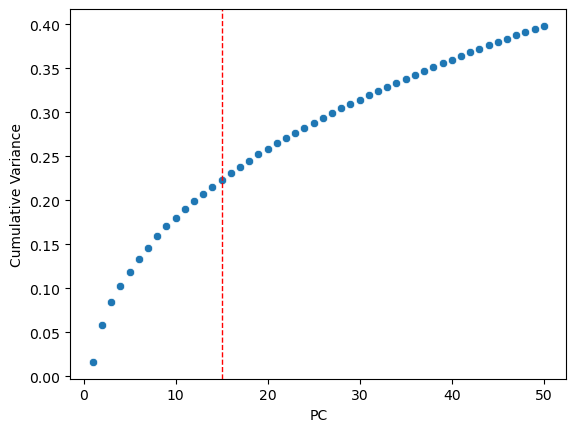

In [17]:
fig, ax = plt.subplots()
sns.scatterplot(
    y=np.cumsum(tf_adata.uns['pca']['variance_ratio']),
    x=range(1, tf_adata.uns['pca']['variance_ratio'].shape[0] + 1),
    ax=ax
)
ax.set_ylabel('Cumulative Variance')
ax.set_xlabel('PC')

n_pcs = tf_adata.uns['pca']['pca_rank']
ax.axvline(x=n_pcs, color='red', linestyle='--', linewidth=1)

print('The elbow was automatically identified at PC {}'.format(n_pcs))
;

In [18]:
# nmi = normalized_mutual_info_score(tf_adata.obs.condition, tf_adata.obs.TF_clusters)
# print('Condition NMI was maximized at a resolution of {:.2f} at a value of {:.2f}'.format(tf_adata.uns['leiden']['params']['resolution'], 
#                                                                                   nmi))


The two PC components that best univariately separate by drug are components 4 and 1 explaining 3.17% and 3.15% of variance, respectively
The two PC components that best univariately separate by cell_line are components 2 and 3 explaining 79.31% and 51.20% of variance, respectively


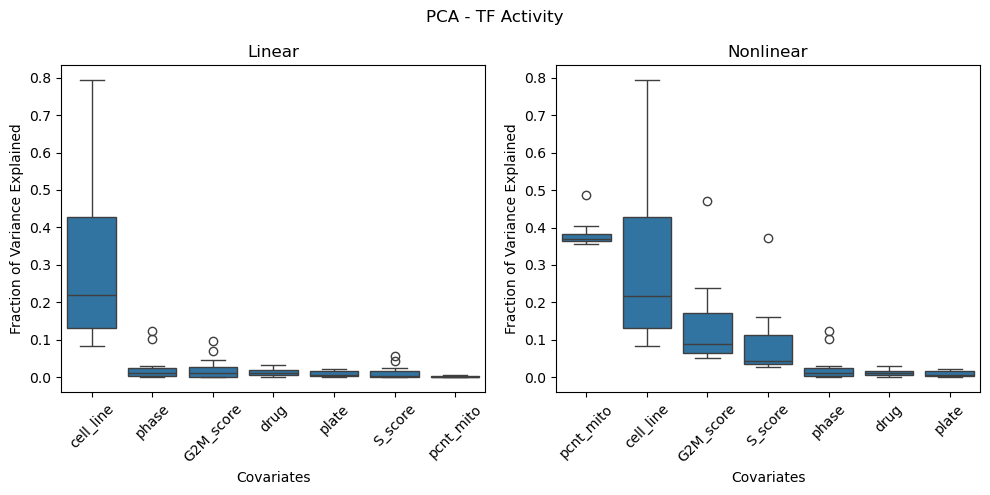

In [19]:
ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PCA - TF Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [32]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     phase      0.004652
           G2M_score  0.004936
           S_score    0.007168
           plate      0.007171
           pcnt_mito  0.009051
           drug       0.014631
           cell_line  0.840990
nonlinear  phase      0.004644
           plate      0.007162
           drug       0.014564
           S_score    0.335452
           G2M_score  0.487401
           pcnt_mito  0.783354
           cell_line  0.840988

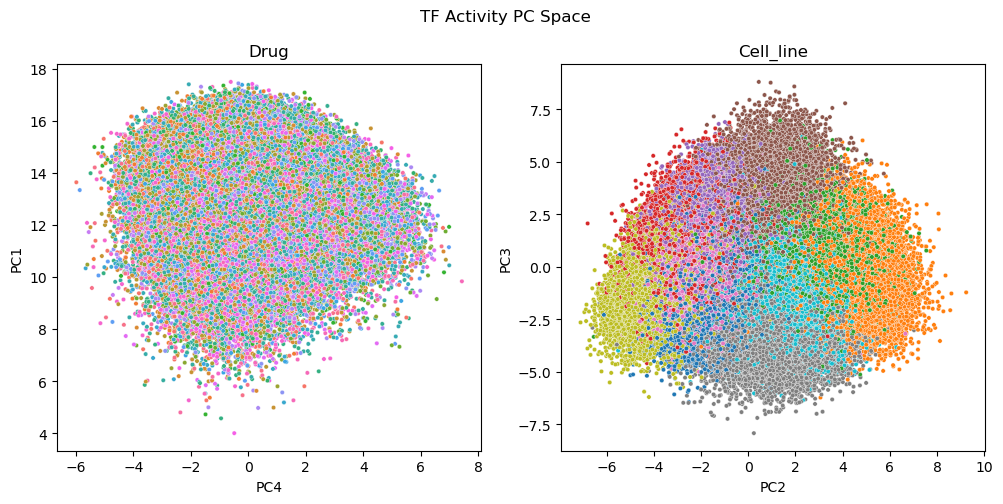

In [20]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'pca', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'TF Activity PC Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

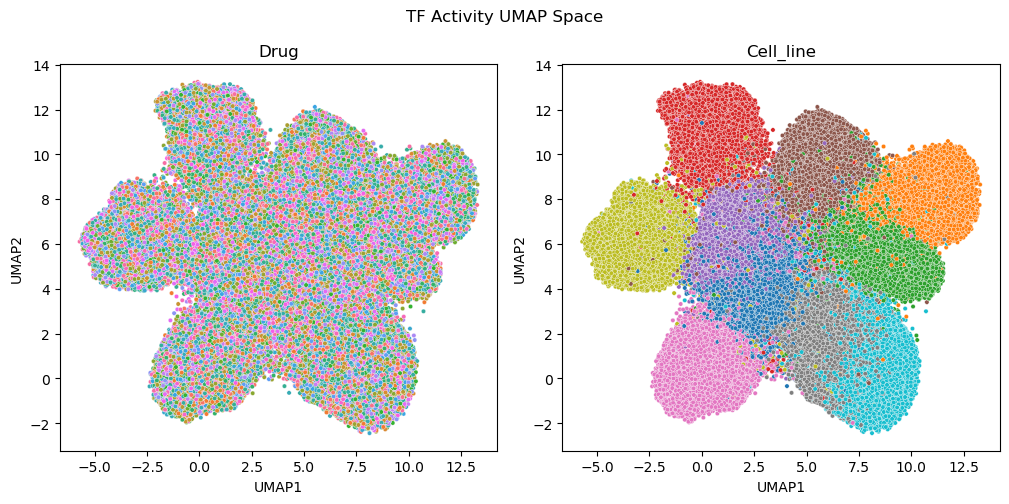

In [21]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'umap', 
    covariates = ['drug', 'cell_line'],
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'TF Activity UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

These are clearly separating much more strongly by cell line than perturbation. In fact, perturbation is a weaker source of variance than many technical confounders. Let's next see whether PLS-DA geared towards drug can import perturbation separation

## PLS-DA 

For PLS-DA:
- again, we do not scale since it is TF activity that is Z-scored
- we use our automated elbow analysis to identify the number of covariates
- umap is run categorically on drug

In [22]:
file_prefix = os.path.join(data_path, 'processed', author + '_TF_activity_pls')

In [23]:
tf_adata, r2_df = ls.pls_da_pipeline(
    adata = tf_adata, 
    pert_ids = tf_adata.obs.drug.unique(), # don't subset
    cat_ids = tf_adata.obs.cell_line.unique(), # don't subset
    n_components = None, 
    pert_col = 'drug', 
    cat_col = 'cell_line', 
    separate_by = 'perturbation', 
    control_confounders = [], 
    covariate_associations = covariate_associations,
    scale = False, # TF activity already Z-scored
    run_umap = True, 
    file_prefix = file_prefix, 
    verbose = True,
    seed = seed, 
    n_cores = n_cores
)


Run elbow selection


100%|██████████████████████████████████████████| 25/25 [58:38<00:00, 140.73s/it]


Calculate covariate - PLS associations
cell_line


100%|███████████████████████████████████████████| 12/12 [00:02<00:00,  5.32it/s]


drug


...

G2M_score


100%|███████████████████████████████████████████| 12/12 [03:17<00:00, 16.46s/it]


pcnt_mito


100%|███████████████████████████████████████████| 12/12 [10:15<00:00, 51.26s/it]
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Get UMAP


In [24]:
tf_adata.uns['pls']['model_fit']

{'n_components': 12,
 'accuracy': 0.13809531632468666,
 'explained_y': 0.02347167874969336}

''

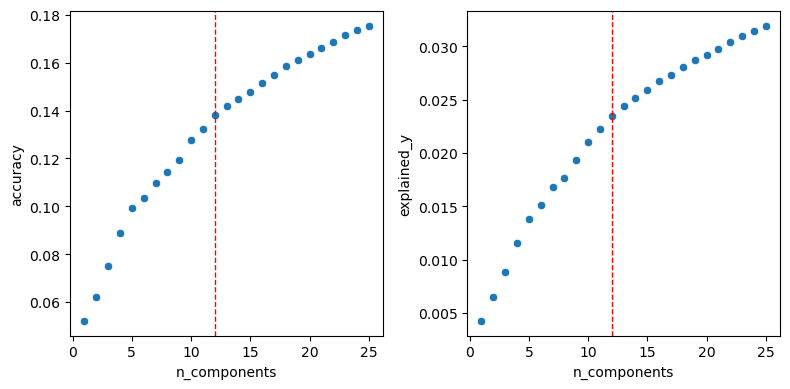

In [41]:
elbow_df = tf_adata.uns['pls']['elbow_analysis']

n_components = tf_adata.uns['pls']['model_fit']['n_components']
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
for (i, metric) in enumerate(['accuracy', 'explained_y']):
    sns.scatterplot(data = elbow_df, x = 'n_components', y = metric, ax = ax[i])
    ax[i].axvline(x=n_components, color='red', linestyle='--', linewidth=1)
   
    
fig.tight_layout()
;

The two PLS components that best univariately separate by drug are components 1 and 4 explaining 11.94% and 7.69% of variance, respectively
The two PLS components that best univariately separate by cell_line are components 6 and 8 explaining 46.10% and 29.33% of variance, respectively


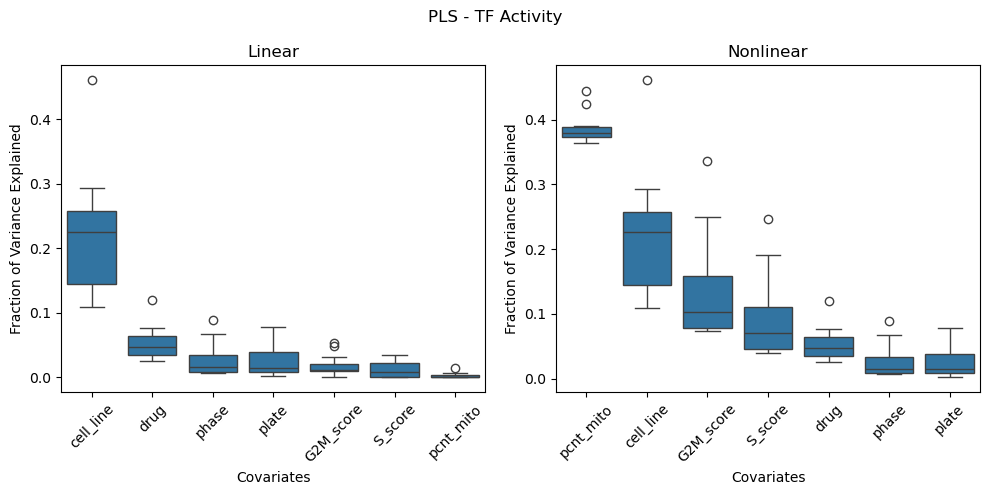

In [25]:
top_components = ls.visualize_latent_association(
    r2_df = r2_df, 
    fig_title = 'PLS - TF Activity', 
    file_name = file_prefix + '_associations.png'
)

top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
top_components_cl = ls.get_top_components(r2_df, top_components_cov = 'cell_line')

In [43]:
pd.melt(
    r2_df.set_index(r2_df.columns[0]), 
    id_vars='model_type', 
    var_name='covariate'
).groupby(['model_type','covariate']).median().sort_values(by = ['model_type', 'value'])


value
model_type covariate          
linear     pcnt_mito  0.001093
           S_score    0.007714
           G2M_score  0.012102
           plate      0.014407
           phase      0.015511
           drug       0.047355
           cell_line  0.226206
nonlinear  plate      0.014407
           phase      0.015511
           drug       0.047355
           S_score    0.071111
           G2M_score  0.102276
           cell_line  0.226206
           pcnt_mito  0.378808

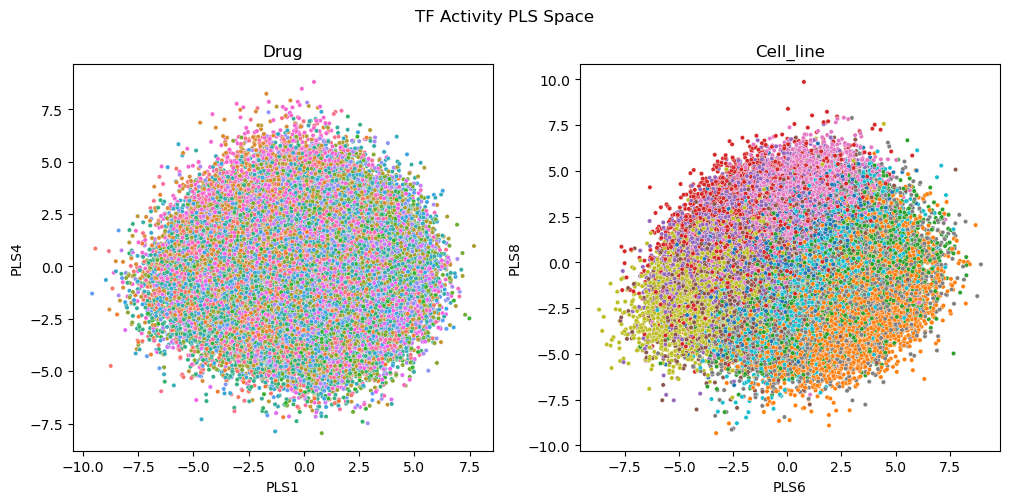

In [26]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = {'drug': top_components_drug, 
                  'cell_line': top_components_cl}, 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'TF Activity PLS Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_space.png'
)

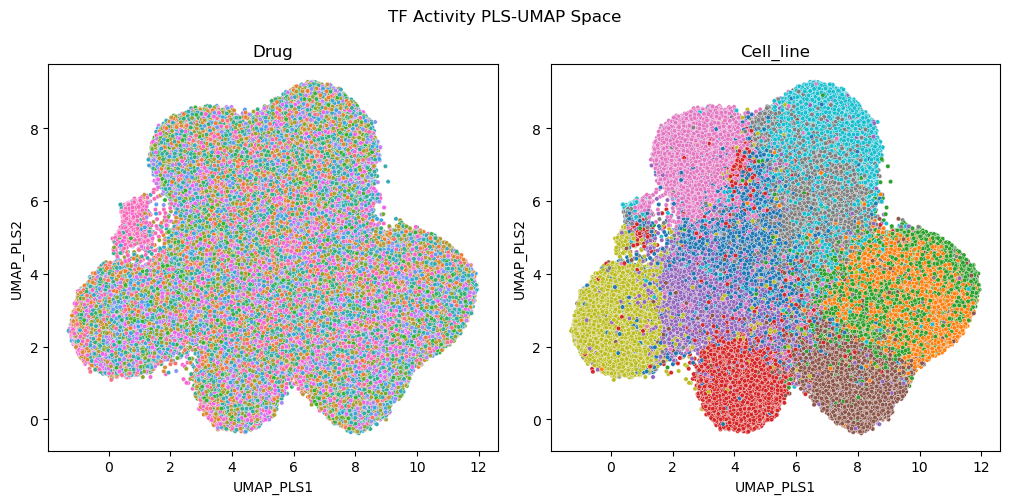

In [27]:
ls.visualize_latent_space(
    adata = tf_adata, 
    latent_label = 'umap_pls', 
    covariates = ['drug', 'cell_line'], 
    panel_titles = ['Drug', 'Cell Line'],
    components = [1,2], 
    n_frac = 0.2, 
    frac_col = None, 
    fig_title = 'TF Activity PLS-UMAP Space', 
    legend = False, 
    seed = 888, 
    file_name = file_prefix + '_umap_space.png'
)

We see that PLS-DA is not able to separate by drug very well either (while it did improve over PCA, but cannot see visually). The signal is not very strong. However, when subsetting to one cell line and just one drug + , PLS-DA succeeds while PCA still fails (data not shown) -- this indicates that, while weak, there is perturbation signal, and the goal is that scLEMBAS model can recover it. 

Write the tf_adata object with the signalng network filters AND embeddings:

In [28]:
io.write_tfad(tf_adata, 
              os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

Also write the adata object formatted as input to scLEMBAS (for correct loading and due to compute time/memory):

In [ ]:
# from script 01 - normalization, hvgs, and TF scores
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_normalized_scored.h5ad')) 
# tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

hvgs = adata.var['highly_variable'][adata.var['highly_variable']].index.tolist()

adata_in = adata[tf_adata.obs_names, hvgs].copy()
adata_in.obsm.clear()

obs_cols = ['sample', 'drug', 'cell_line', 'S_score',  'G2M_score', 
            'phase', 'plate', 'condition','drug_target']

adata_in.obs = adata_in.obs[obs_cols].copy()
adata_in.write_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))

del adata
del adata_in